# Center patch

In [1]:
import pickle
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator
from pyoperators import MPI         # serve per fare calcolo parallelo

from qubic.lib.MapMaking.FrequencyMapMaking.Qfmm import PipelineFrequencyMapMaking
from qubic.lib.Qsamplings import gal2equ

from qubic.scripts.Scanning_Strategy import Sky_Dips_Sim

In [ ]:
plt.rcParams.update({
    'font.size': 20,           # dimensione dei testi generali
    'axes.titlesize': 30,      # dimensione dei titoli degli assi
    'axes.labelsize': 16,      # dimensione delle label degli assi
    'xtick.labelsize': 25,     # dimensione dei tick x
    'ytick.labelsize': 14,     # dimensione dei tick y
})

In [9]:
def inspect_maps(file):
    data = pickle.load(open(file, "rb"))

    nus = data["nus"]
    Nrec = nus.shape[0] - 7

    maps_input = data["maps_in_convolved"]
    maps_rec = data["maps"][:Nrec]
    maps_res = maps_input - maps_rec
    maps_noise = data['maps_noise'][:Nrec]

    center = data["center"]
    seenpix = data["seenpix"]
    convergence = data["convergence"]
    coverage = data["coverage"]
    parameters = data["parameters"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    hp.mollview(coverage, title='Coverage', cmap='Spectral_r', fig=fig.number, sub=(1, 2, 1))
    plt.subplot(1, 2, 1).axis('off')

    axes[1].plot(convergence)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Convergence")
    axes[1].set_title("PCG Convergence")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-8, 1e0)
    axes[1].grid()

    plt.subplots_adjust(wspace=0.4)
    plt.show()

    
    STOKES = ["I", "Q", "U"]

    maps_input[:, ~seenpix, :] = hp.UNSEEN
    maps_rec[:, ~seenpix, :] = hp.UNSEEN
    maps_res[:, ~seenpix, :] = hp.UNSEEN

    istk = 0
    n = 2
    # sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
    # sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
    # sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

    reso = 15

    k = 0

    plt.figure(figsize=(20, 10))
    for inu in range(Nrec):
        hp.gnomview((maps_input[inu, :, istk]), rot=center,
                            reso=reso,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                            cmap="jet",
                            # min = - n * sigma_input[inu],
                            # max = n * sigma_input[inu],
                            sub=(Nrec, 3, k + 1))
        
        hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                            reso=reso,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                            cmap="jet",
                            # min = - n * sigma_rec[inu],
                            # max = n * sigma_rec[inu],
                            sub=(Nrec, 3, k + 2))
        
        hp.gnomview(maps_res[inu, :, istk], rot=center,
                            reso=reso,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                            cmap="jet",
                            # min = - n * sigma_res[inu],
                            # max = n * sigma_res[inu],
                            sub=(Nrec, 3, k + 3))
        k += 3

    del data


def load_maps(file, plot=False):
    data = pickle.load(open(file, "rb"))

    nus = data["nus"]
    Nrec = nus.shape[0] - 7

    maps_input = data["maps_in_convolved"]
    maps_rec = data["maps"][:Nrec]
    maps_res = maps_input - maps_rec
    maps_noise = data['maps_noise'][:Nrec]

    center = data["center"]
    coverage = data["coverage"]
    seenpix = data["seenpix"]

    maps_input[:, ~seenpix, :] = hp.UNSEEN
    maps_rec[:, ~seenpix, :] = hp.UNSEEN
    maps_res[:, ~seenpix, :] = hp.UNSEEN

    if plot==True:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        hp.mollview(coverage, title='Coverage', cmap='Spectral_r', fig=fig.number, sub=(1, 2, 1))
        plt.subplot(1, 2, 1).axis('off')

        axes[1].plot(data["convergence"])
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("Convergence")
        axes[1].set_title("PCG Convergence")
        axes[1].set_yscale("log")
        axes[1].set_ylim(1e-8, 1e0)
        axes[1].grid()

        plt.subplots_adjust(wspace=0.4)
        plt.show()

        STOKES = ["I", "Q", "U"]

        istk = 0
        n = 2
        # sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
        # sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
        # sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

        reso = 15

        k = 0

        plt.figure(figsize=(20, 10))
        for inu in range(Nrec):
            hp.gnomview((maps_input[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                                cmap="jet",
                                # min = - n * sigma_input[inu],
                                # max = n * sigma_input[inu],
                                sub=(Nrec, 3, k + 1))
            
            hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                                cmap="jet",
                                # min = - n * sigma_rec[inu],
                                # max = n * sigma_rec[inu],
                                sub=(Nrec, 3, k + 2))
            
            hp.gnomview(maps_res[inu, :, istk], rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                                cmap="jet",
                                # min = - n * sigma_res[inu],
                                # max = n * sigma_res[inu],
                                sub=(Nrec, 3, k + 3))
            k += 3

    del data

    return maps_input[:,:,0], maps_rec[:,:,0], maps_res[:,:,0], center, seenpix, coverage


def maps_stacking(datafiles):
    maps_input, maps_rec, maps_res = [], [], []
    coverage = []

    for i in range(len(datafiles)):
        data = pickle.load(open(datafiles[i], "rb"))

        if i == 0:
            nus = data["nus"]
            Nrec = nus.shape[0] - 7
            center = data["center"]

        maps_input.append(data["maps_in_convolved"][:,:,0])
        maps_rec.append(data["maps"][:Nrec][:,:,0])
        maps_res.append(maps_input[-1] - maps_rec[-1])

        coverage.append(data["coverage"])

        del data

    maps_input = np.mean(np.array(maps_input), axis=0)
    maps_rec = np.mean(np.array(maps_rec), axis=0)
    maps_res = np.mean(np.array(maps_res), axis=0)
    coverage = np.sum(np.array(coverage), axis=0)
    seenpix = coverage / coverage.max() > 0.1

    return {
                "maps_in": maps_input,
                "maps": maps_rec,
                "maps_res": maps_res,
                "nus": nus,
                "coverage": coverage,
                "center": center,
                "seenpix": seenpix,
            }


def noise_estimation(maps_res_mean, coverage, seenpix):
    noises = []

    # Method 1: noise as residual weighted std
    weighted_mean = np.average(maps_res_mean[seenpix], weights=coverage[seenpix])
    weighted_std = np.sqrt( np.sum(coverage[seenpix] * (maps_res_mean[seenpix] - weighted_mean)**2) / np.sum(coverage[seenpix]) )
    print('Residual weighted std', weighted_std)
    noises.append(weighted_std)

    snr = maps_input_mean/weighted_std
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Weighted std",
                        cmap="jet",
                        min = 0,
    )


    # Method 2: noise estimation from a hit-count–normalized residual map
    normalized_residuals = maps_res_mean[seenpix] * np.sqrt(coverage[seenpix])
    sigma0 = np.std(normalized_residuals)
    sigma = np.zeros_like(coverage)
    sigma[seenpix] = sigma0 / np.sqrt(coverage[seenpix])
    noises.append(sigma)

    snr = maps_input_mean / sigma 
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Hit count normalized std",
                        cmap="jet",
                        min = 0,
    )

    
    # Method 3: noise estimation from hit-binned residual map
    nbins = 20
    hits = coverage[seenpix]
    noise = maps_res_mean[seenpix]
    edges = np.quantile(hits, np.linspace(0, 1, nbins + 1))    # bin edges

    hits_centers = []
    sigma_bins = []

    for i in range(nbins):
        sel = (hits >= edges[i]) & (hits < edges[i+1])
        if np.sum(sel) < 50:
            continue
        hits_centers.append(np.mean(hits[sel]))
        sigma_bins.append(np.sqrt(np.mean(noise[sel]**2)))

    hits_centers = np.array(hits_centers)
    sigma_bins = np.array(sigma_bins)

    bin_idx = np.digitize(coverage[seenpix], edges) - 1  # returns 0..nbins-1
    bin_idx[bin_idx == nbins] = nbins-1     # last bin includes pixel on border
    sigma = np.zeros_like(coverage)       
    sigma[seenpix] = sigma_bins[bin_idx]
    noises.append(sigma)

    snr = maps_input_mean / sigma
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Hit binned std",
                        cmap="jet",
                        min = 0,
    )

    
    # Method 4: noise as local std
    radius_deg = 1
    radius_rad = np.radians(radius_deg)

    sigma = np.zeros_like(maps_res_mean)

    for ipix in range(len(maps_res_mean)):
        # finds all the pixel within radius_rad from pixel ipix 
        neighbors = hp.query_disc(128, hp.pix2vec(128, ipix), radius_rad)
        
        # local std
        sigma[ipix] = np.sqrt(np.mean(maps_res_mean[neighbors]**2))
    noises.append(sigma)

    snr = maps_input_mean / sigma
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Local std",
                        cmap="jet",
                        min = 0,
    )

    return noises

## Inspect maps

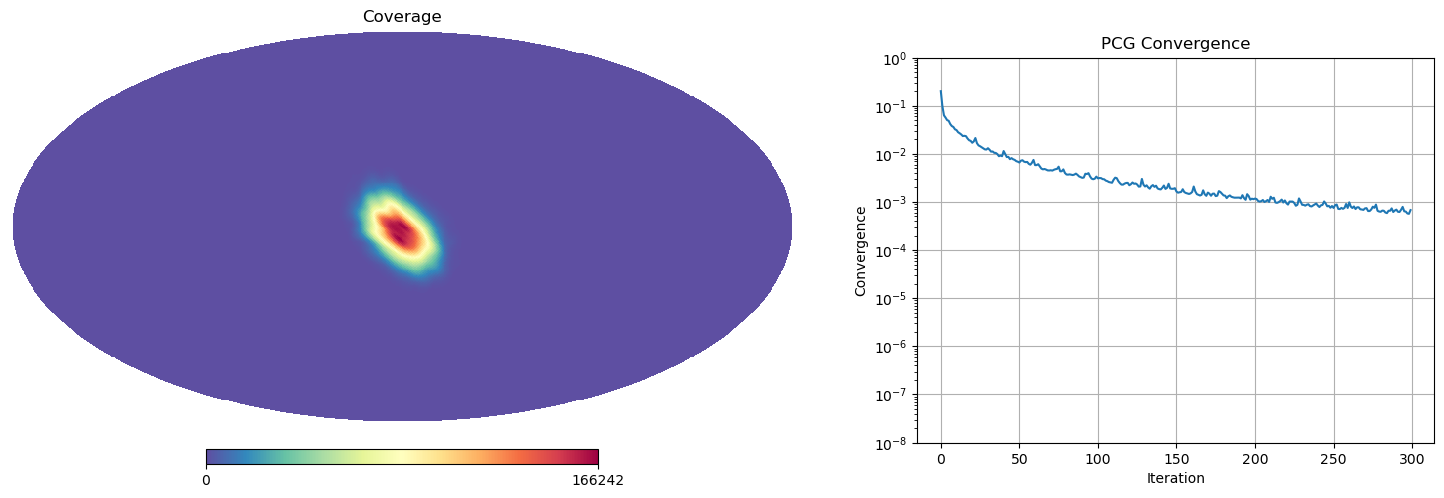

(array([[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]]),
 array([[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]]),
 array([[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.

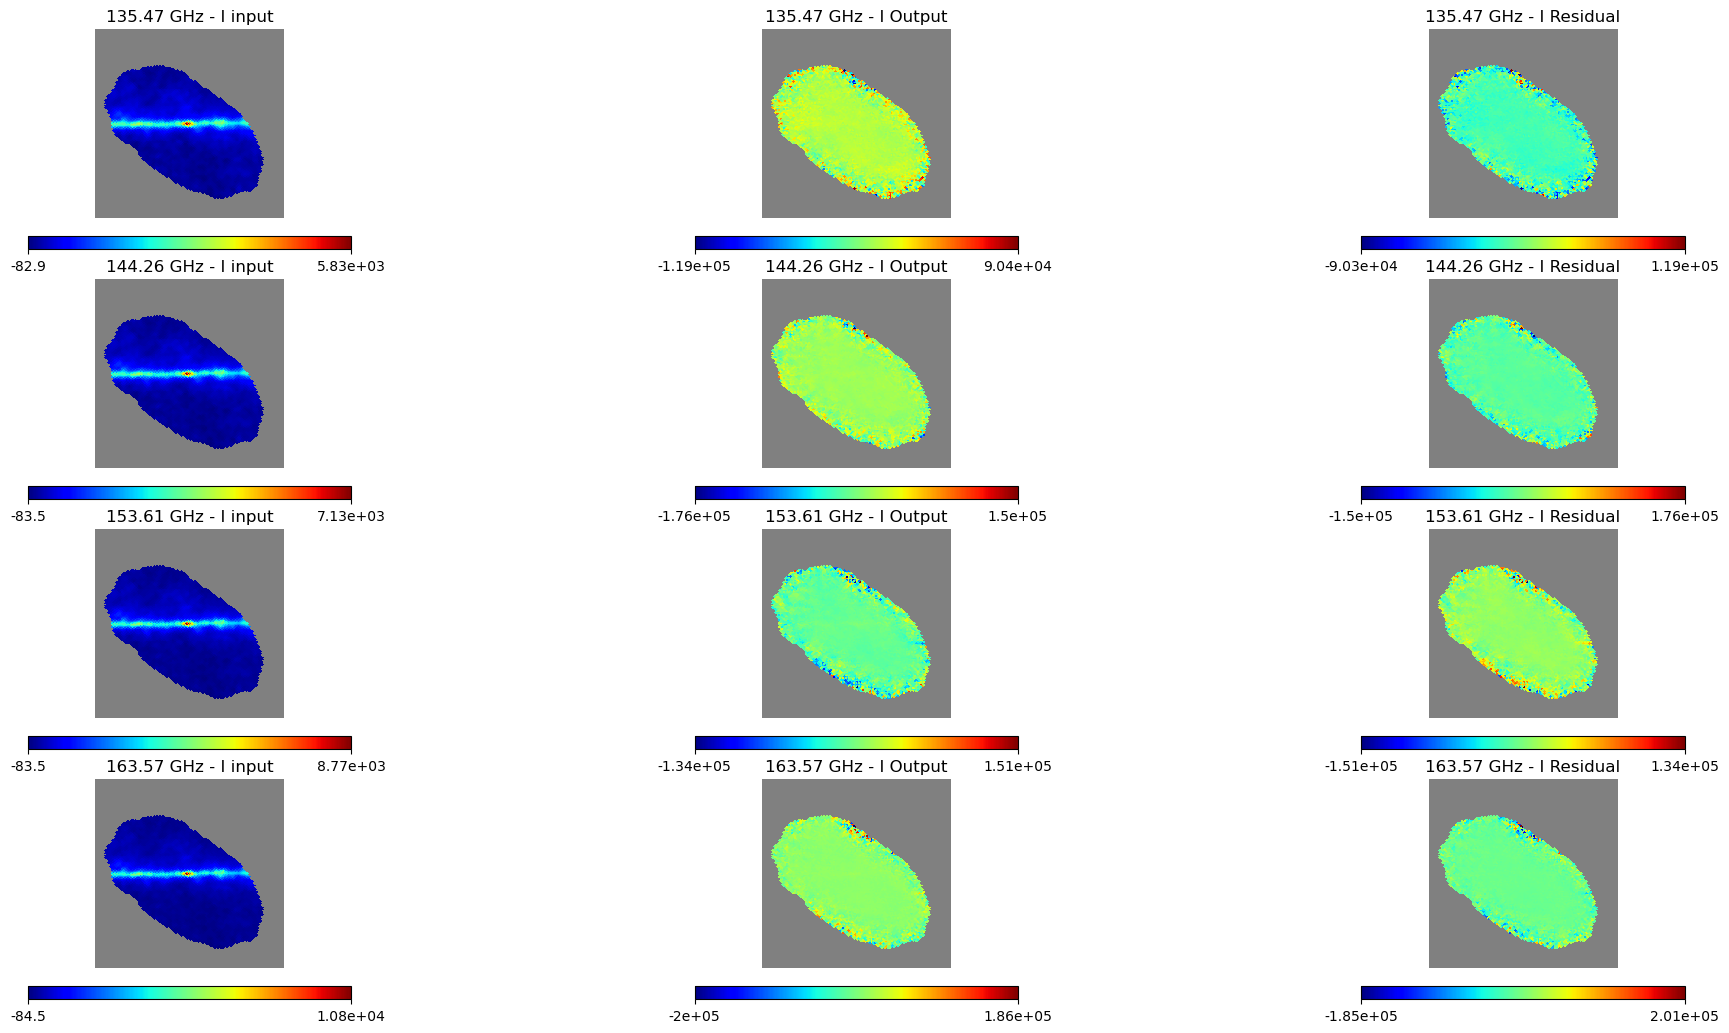

In [ ]:
load_maps("/media/mattia/Hard Disk/data/center/maps/01-02_planck.pkl", plot=True),

## Scanning strategy with fixed HWP

In [3]:
datafiles=[
    "/media/mattia/Hard Disk/data/center/maps/01-02_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/03-04_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/05-06_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/07-08_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/09-10_planck.pkl",
    "/media/mattia/Hard Disk/data/center/maps/11-12_planck.pkl",
]

In [5]:
data = maps_stacking(datafiles)

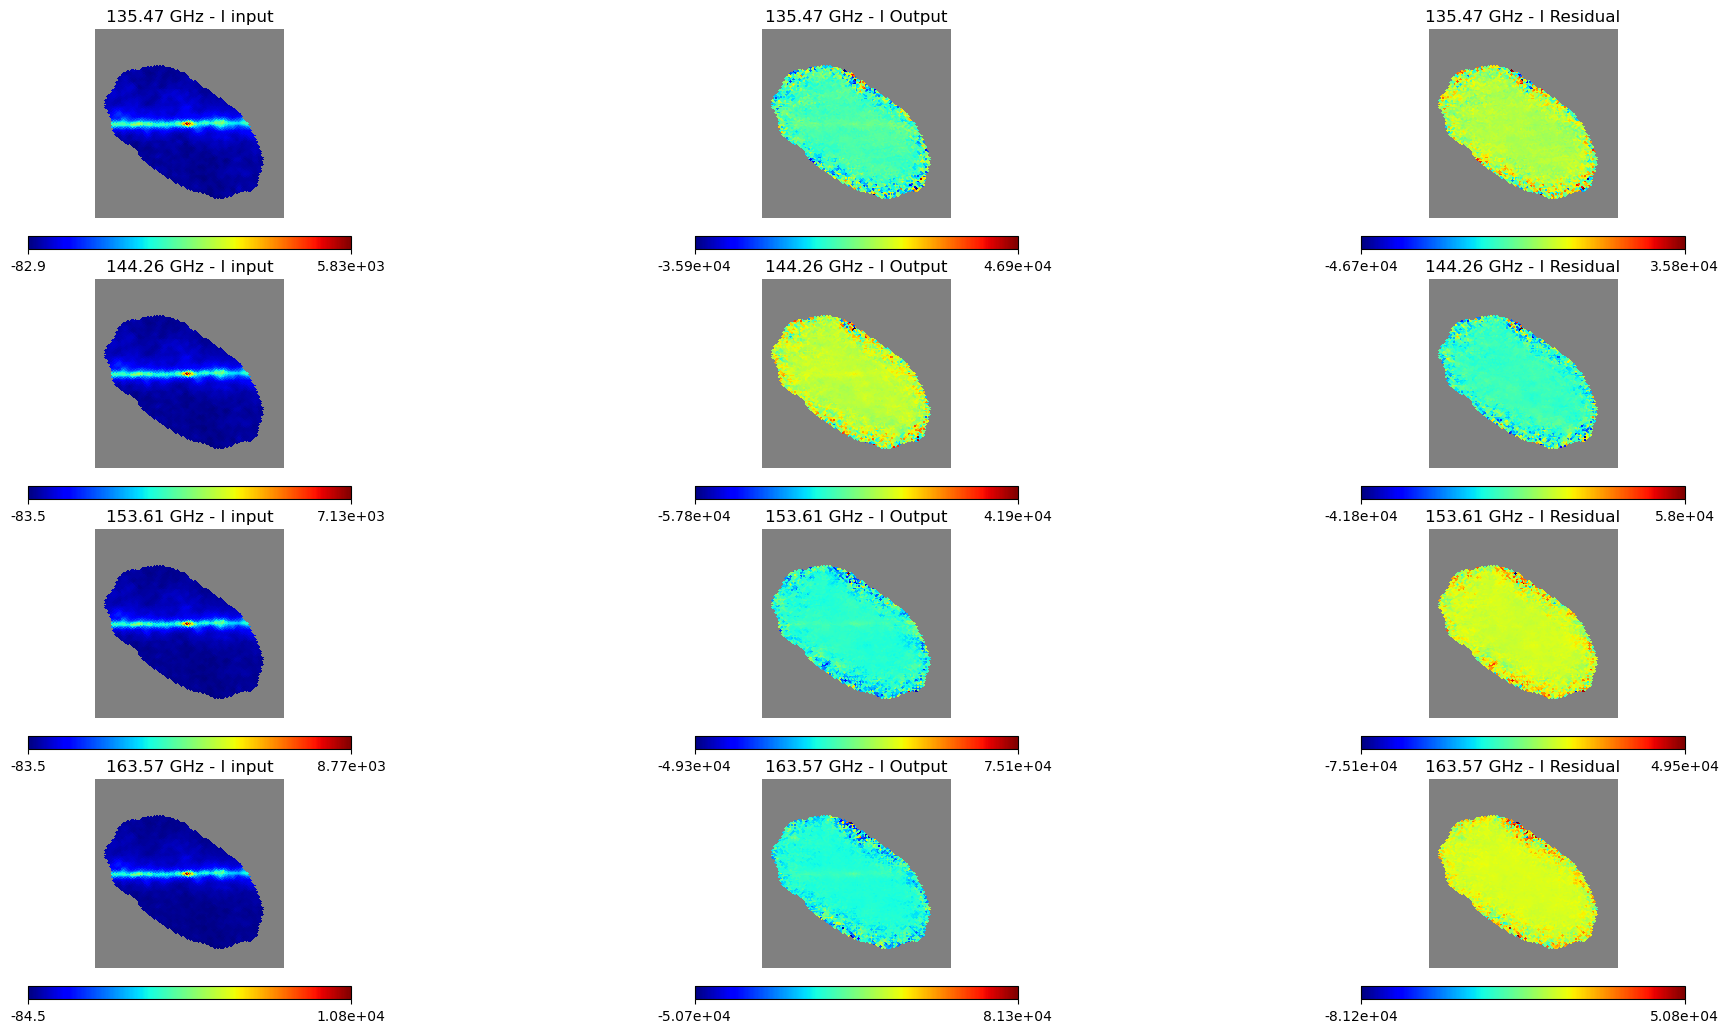

In [6]:
maps_input = data["maps_in"]
maps_rec = data["maps"]
maps_res = data["maps_res"]
seenpix = data["seenpix"]
maps_input[:,~seenpix] = hp.UNSEEN
maps_rec[:,~seenpix] = hp.UNSEEN
maps_res[:,~seenpix] = hp.UNSEEN
nus = data["nus"]
center = data["center"]
coverage = data["coverage"]

k=0 

plt.figure(figsize=(20, 10))
for inu in range(4):
    hp.gnomview((maps_input[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I input",  
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        #norm="hist",
                        #min = - n * sigma_input[inu],
                        #max = n * sigma_input[inu],
                        sub=(4, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Output",
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        #norm="hist",
                        #min = - n * sigma_rec[inu],
                        #max = n * sigma_rec[inu],
                        sub=(4, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Residual",
                        cmap="jet",
                        #unit=r'$\mu \mathrm{K_{CMB}}$',
                        #norm="hist",
                        #min = - n * sigma_res[inu],
                        #max = n * sigma_res[inu],
                        sub=(4, 3, k + 3))
    k += 3

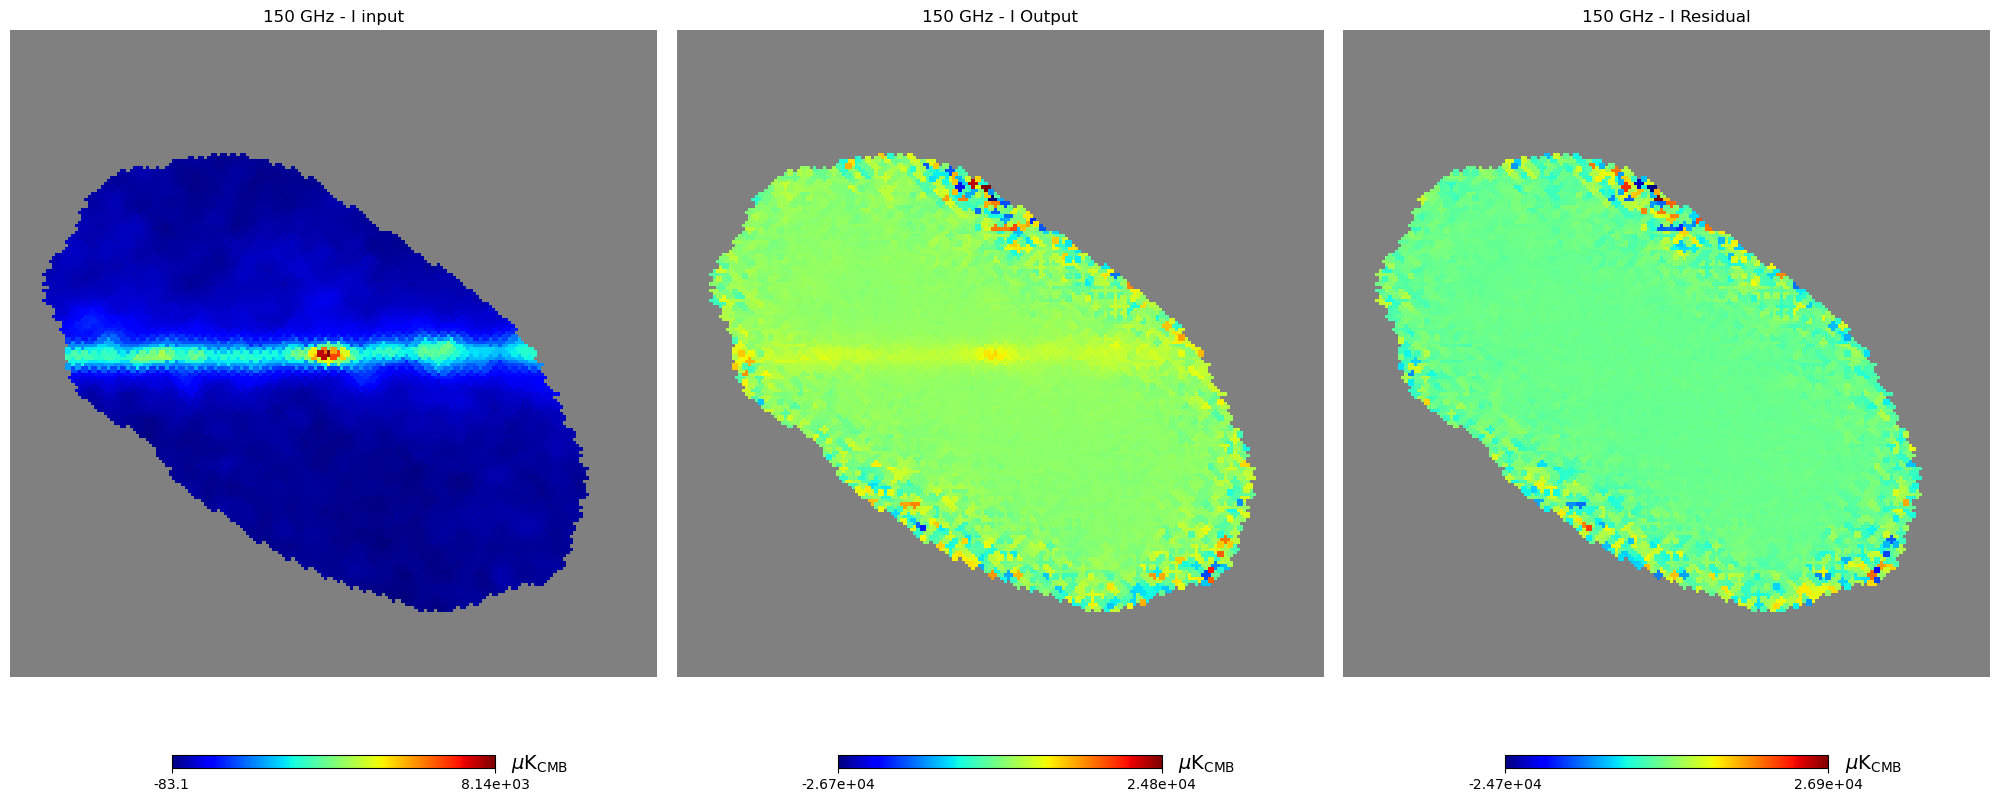

In [7]:
# Mean over reconstructed frequency maps
maps_input_mean = np.mean(maps_input[:,:], axis=0)
maps_rec_mean = np.mean(maps_rec[:,:], axis=0)
maps_res_mean = np.mean(maps_res[:,:], axis=0)


plt.figure(figsize=(20, 10))
hp.gnomview((maps_input_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))
    
    
hp.gnomview((maps_rec_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,2))

hp.gnomview((maps_res_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,3))
    

In [8]:
brightest_pix_input = np.argmax(maps_input_mean)   # index of the brightest pixel in the input mean map 
brightest_val = maps_rec_mean[brightest_pix_input] # value of the brightest pixel in the output mean map
brightest_val_true = maps_input_mean[brightest_pix_input] # value of the brightest pixel in the input mean map


print('Brightest pixel coverage', coverage[brightest_pix_input])
print('Value of the brightest pixel in the input map', brightest_val_true)
print('Value of the brightest pixel in the output map', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Brightest pixel coverage 1015822.0583079185
Value of the brightest pixel in the input map 8140.484210744878
Value of the brightest pixel in the output map 8328.859622102857
SNR 43.21415492638326


### Noise estimation

Residual weighted std 1537.7057648507064


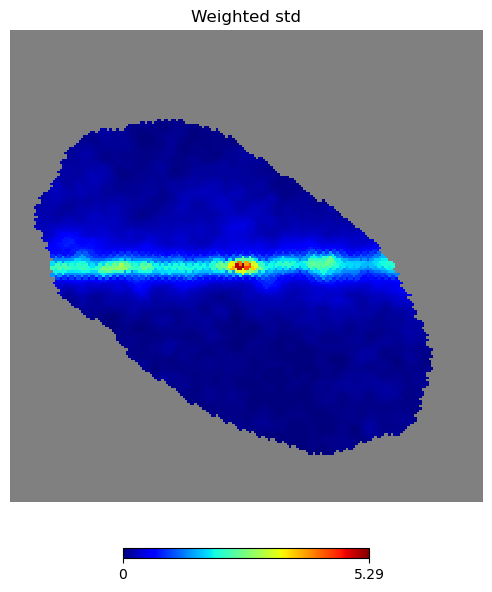

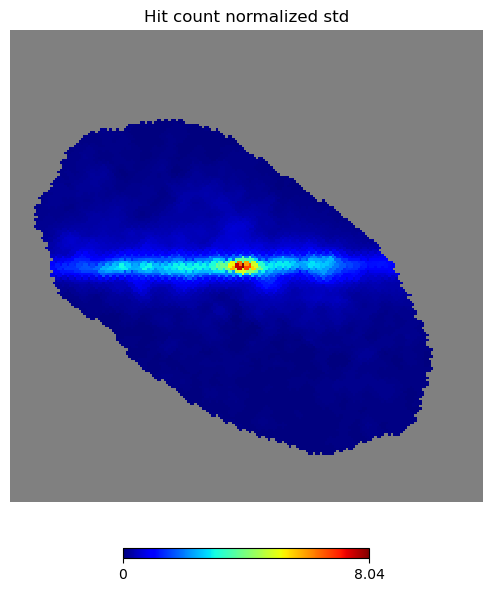

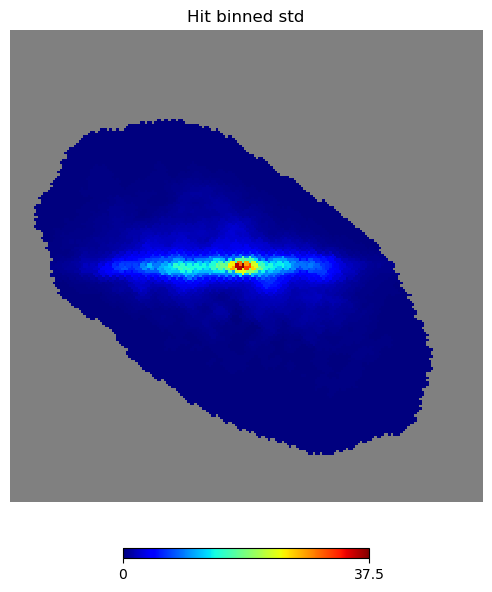

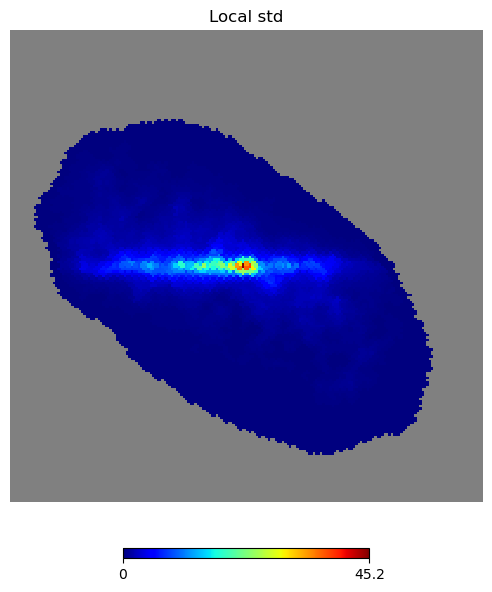

In [10]:
noises = noise_estimation(maps_res_mean, coverage, seenpix)

### SED

Prendo il pixel più luminoso

In [16]:
brightest_pix_input = np.argmax(maps_input[0,:])   # indice del pixel con valore massimo nelle mappe di input
brightest_pix = np.argmax(maps_rec[0,:])   # indice del pixel con valore massimo nelle mappe ricostruite
theta, phi = hp.pix2ang(128, brightest_pix_input)  # coordinate del pixel più luminoso

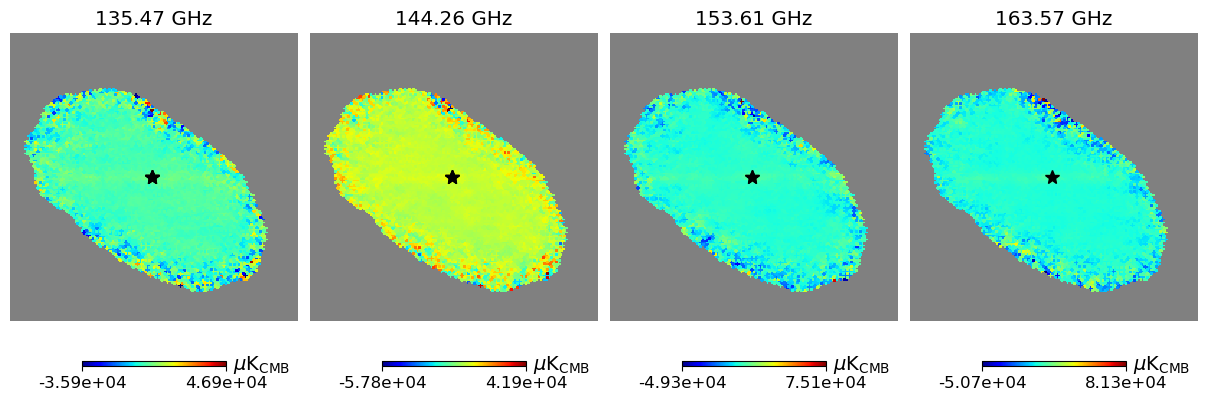

In [22]:
plt.figure(figsize=(12, 5))
for inu in range(4):
    hp.gnomview((maps_rec[inu, :]), 
                        rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        sub = (1,4,inu+1),
                        )

    ax = plt.gca()

    # Aggiungi label manualmente
    #ax.text(0, -0.4, "l [deg]", ha='center', va='top', fontsize=18)
    #ax.text(-0.36, 0, "b [deg]", ha='center', va='center', rotation=90, fontsize=18)

    hp.projplot(theta, phi, marker='*', markersize=10, color='black')
    #hp.graticule()

    #plt.savefig('/home/mattia/Desktop/figures/central_maps.pdf', bbox_inches='tight')

In [20]:
brightest_val = maps_rec[:,brightest_pix_input]
brightest_val_true = maps_input[:,brightest_pix_input]

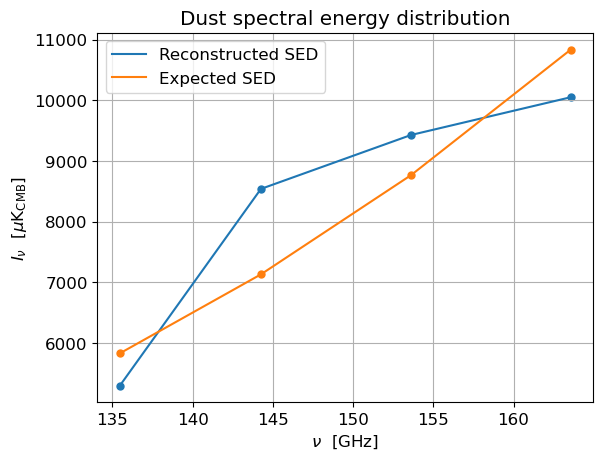

In [28]:
plt.plot(nus[0:4], brightest_val, label='Reconstructed SED')
plt.scatter(nus[0:4], brightest_val, marker='.', s=100)

plt.plot(nus[0:4], brightest_val_true, label='Expected SED')
plt.scatter(nus[0:4], brightest_val_true, marker='.', s=100)


#plt.yscale('log')
plt.xlabel(r'$\nu \ $ [GHz]')
plt.ylabel(r'$I_{\nu} \ \ [\mu \mathrm{K_{CMB}}]$')
plt.title('Dust spectral energy distribution')
plt.grid(which='both', axis='both')
plt.legend()

#plt.savefig('/home/mattia/Desktop/figures/central_sed.pdf', bbox_inches='tight')


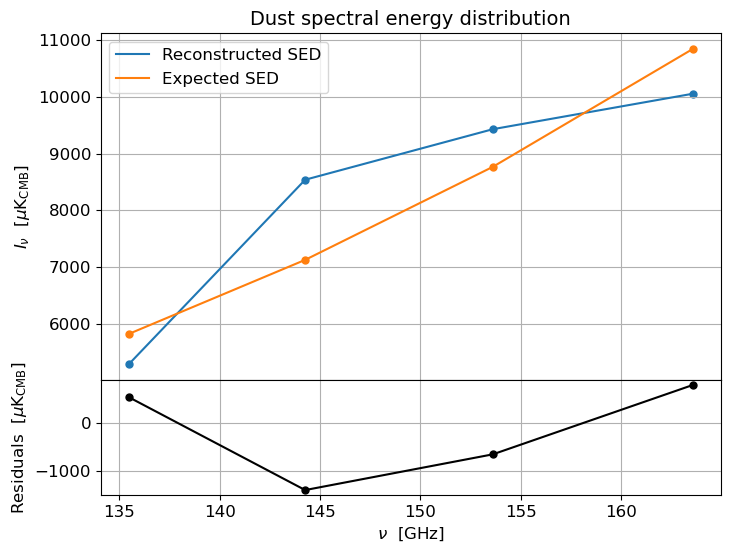

In [29]:
# calcolo dei residui
residui = brightest_val_true - brightest_val 

# creo la figura e i due subplot con griglia verticale
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1], 'hspace':0}, 
                               figsize=(8,6),
                               )

ax1.set_title("Dust spectral energy distribution", fontsize=14)

# grafico principale
ax1.plot(nus[0:4], brightest_val, label='Reconstructed SED')
ax1.scatter(nus[0:4], brightest_val, marker='.', s=100)

ax1.plot(nus[0:4], brightest_val_true, label='Expected SED')
ax1.scatter(nus[0:4], brightest_val_true, marker='.', s=100)

ax1.set_ylabel(r'$I_{\nu} \ \ [\mu \mathrm{K_{CMB}}]$')
#ax1.set_yscale('log')
ax1.legend()
ax1.grid(True)

# grafico residui
ax2.plot(nus[0:4], residui, c='black')
ax2.scatter(nus[0:4], residui, marker='.', s=100, c='black')
#ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel(r'$\nu \ $ [GHz]')
ax2.set_ylabel(r'Residuals $\ [\mu \mathrm{K_{CMB}}]$')
ax2.grid(True)

plt.savefig('/home/mattia/Desktop/figures/central_sed.pdf', bbox_inches='tight')

## Scanning strategy with rotating HWP

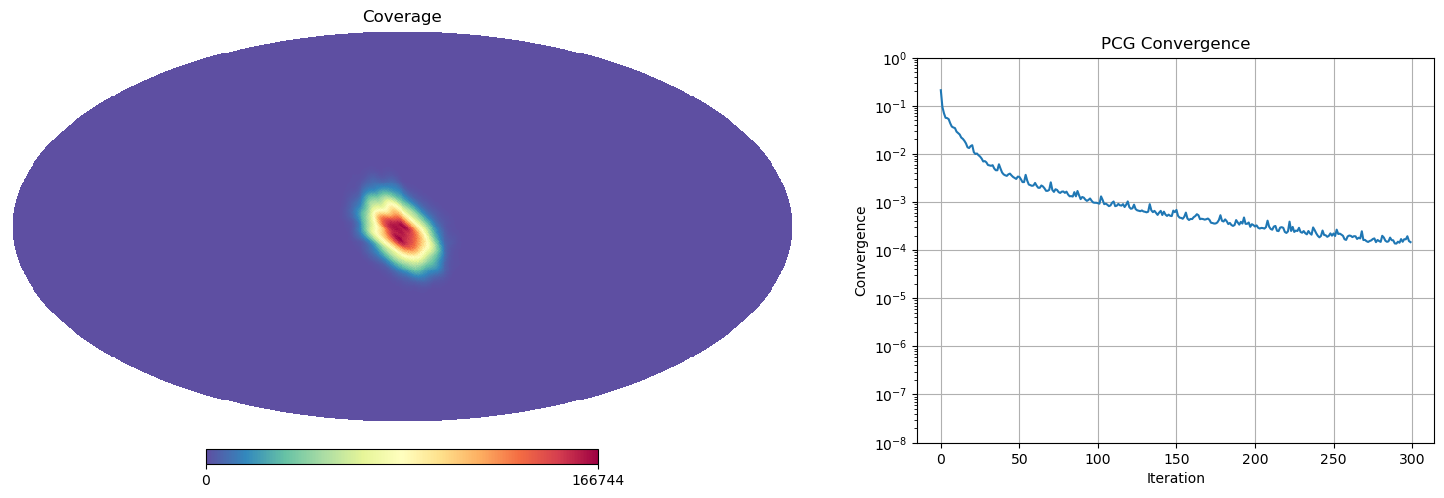

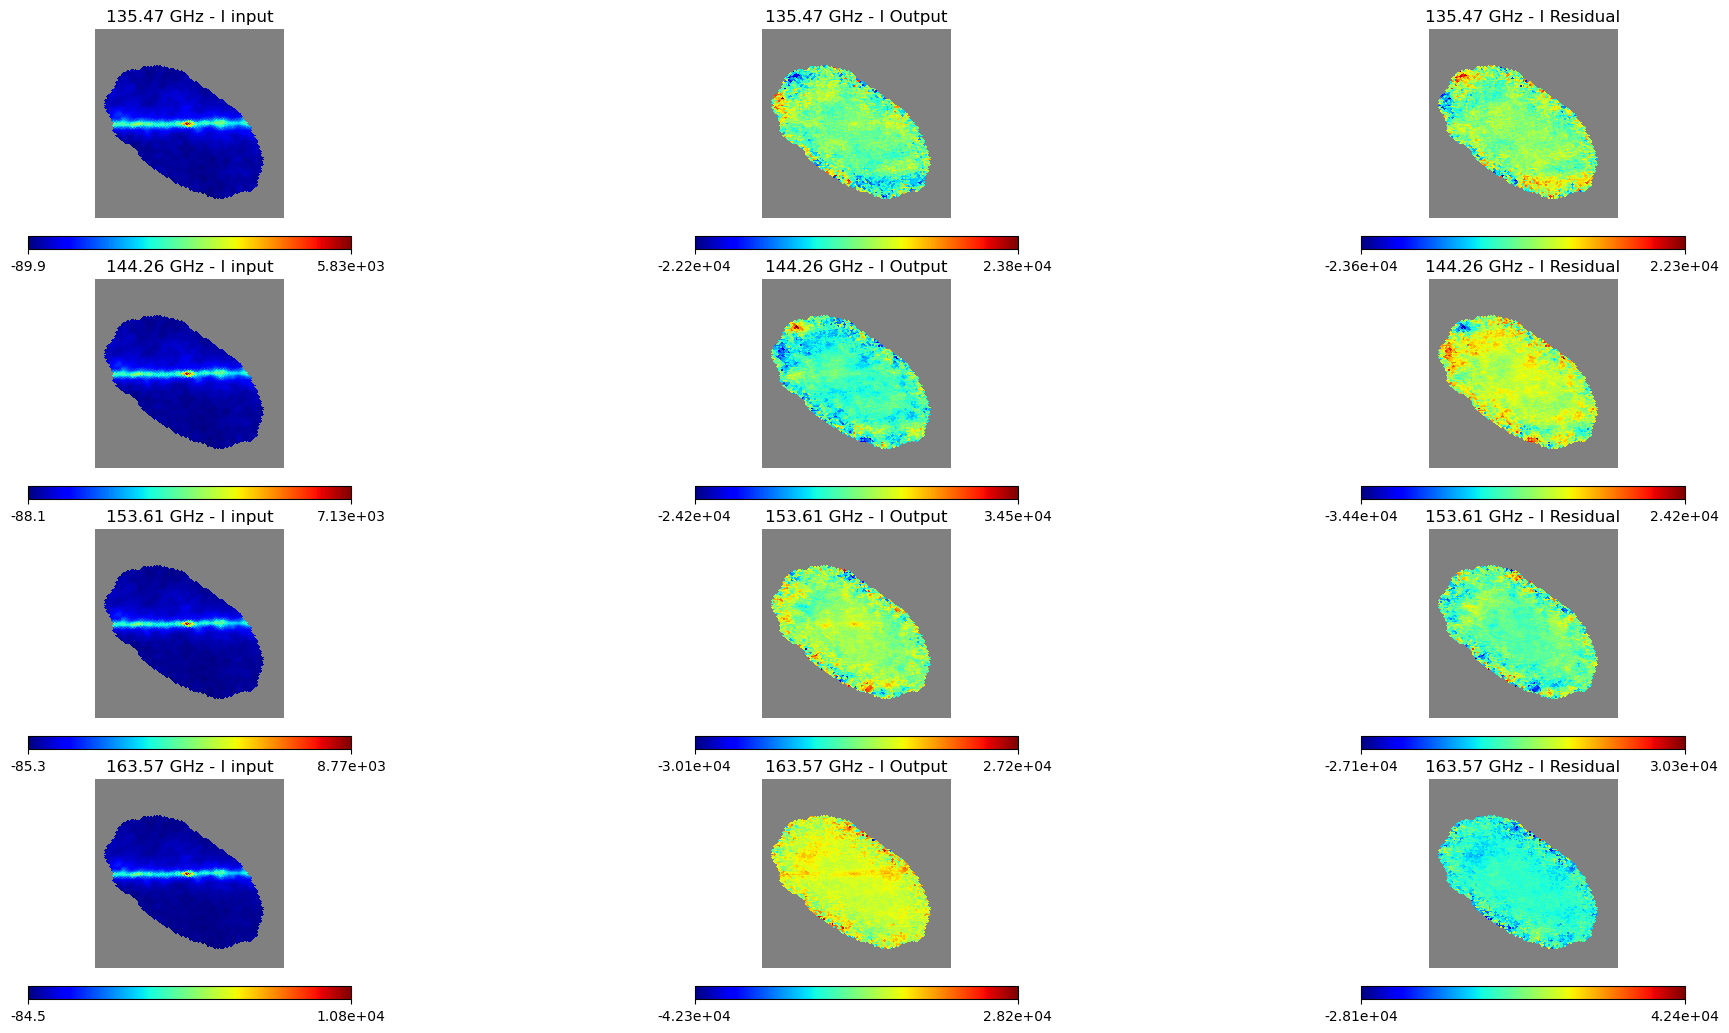

In [6]:
inspect_maps("/media/mattia/Hard Disk/data/center/maps/01-02_ss_hwp.pkl")

In [30]:
datafiles=["/media/mattia/Hard Disk/data/center/maps/01-02_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/03-04_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/05-06_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/07-08_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/09-10_ss_hwp.pkl",
            "/media/mattia/Hard Disk/data/center/maps/11-12_ss_hwp.pkl",
]

In [31]:
data = maps_stacking(datafiles)

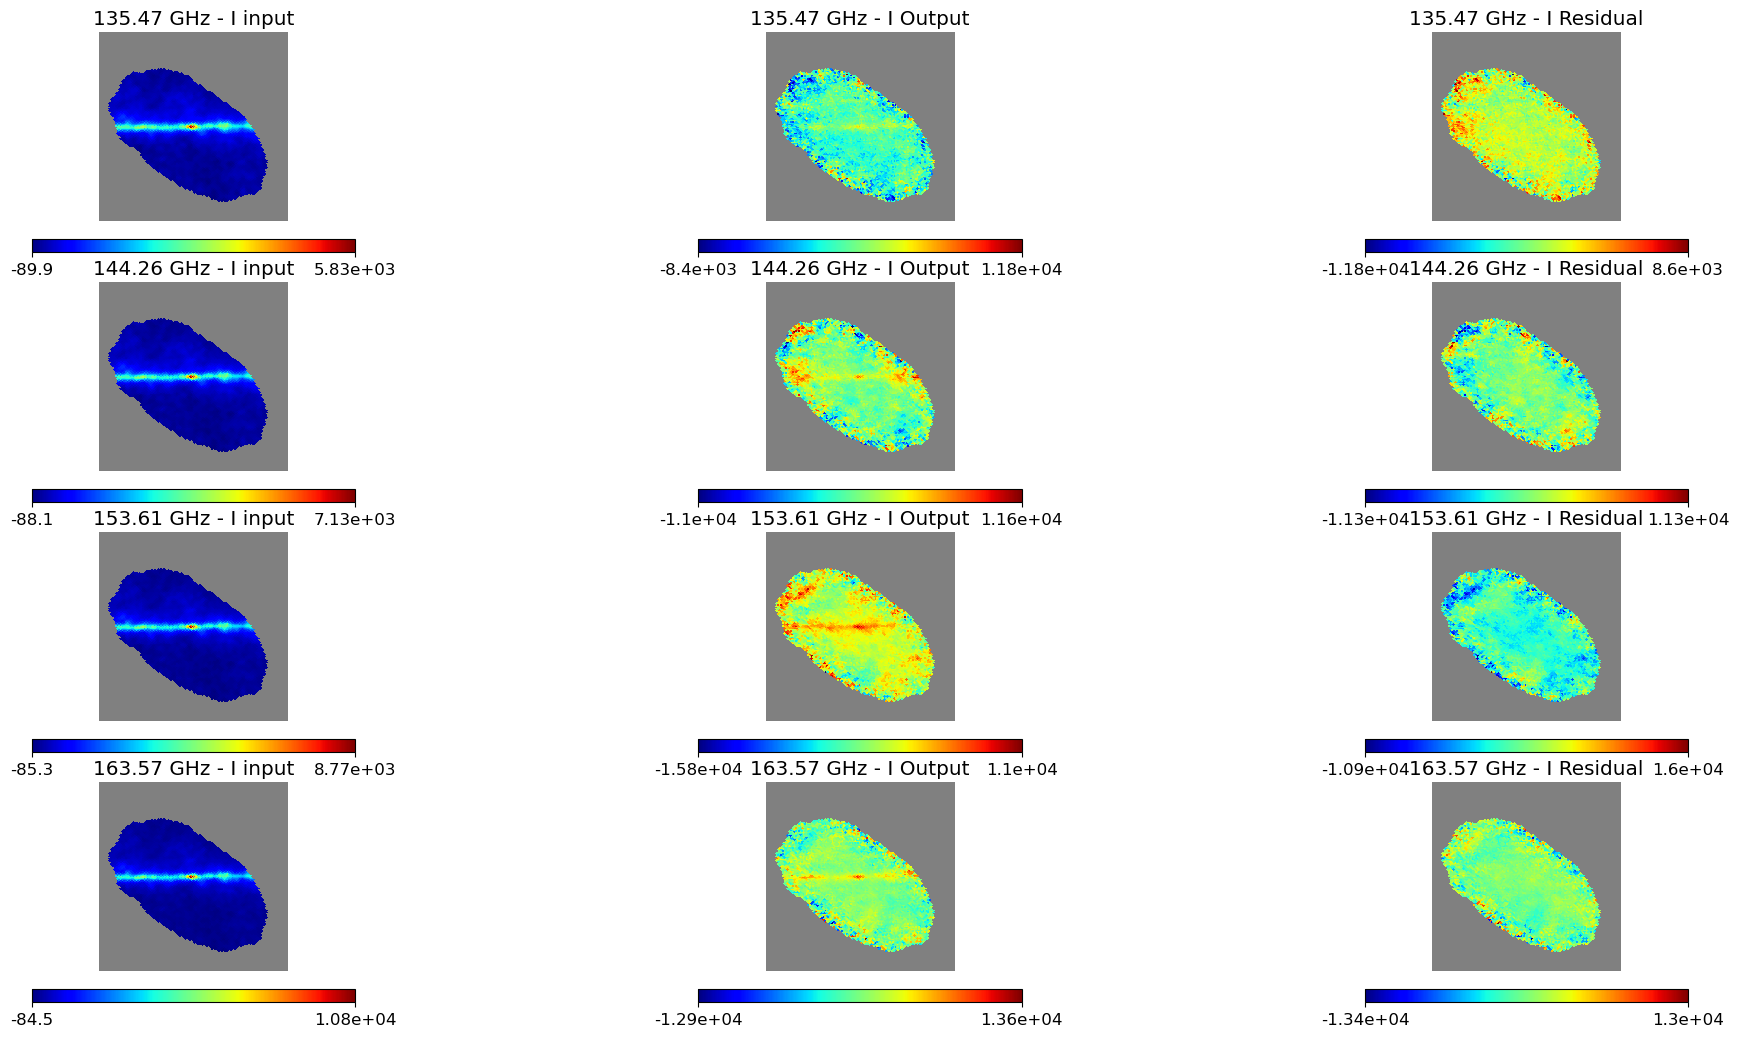

In [32]:
maps_input = data["maps_in"]
maps_rec = data["maps"]
maps_res = data["maps_res"]
seenpix = data["seenpix"]
maps_input[:,~seenpix] = hp.UNSEEN
maps_rec[:,~seenpix] = hp.UNSEEN
maps_res[:,~seenpix] = hp.UNSEEN
nus = data["nus"]
center = data["center"]
coverage = data["coverage"]

k=0 

plt.figure(figsize=(20, 10))
for inu in range(4):
    hp.gnomview((maps_input[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I input",  
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_input[inu],
                        #max = n * sigma_input[inu],
                        sub=(4, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :]), rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Output",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_rec[inu],
                        #max = n * sigma_rec[inu],
                        sub=(4, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - I Residual",
                        cmap="jet",
                        #norm="hist",
                        #min = - n * sigma_res[inu],
                        #max = n * sigma_res[inu],
                        sub=(4, 3, k + 3))
    k += 3

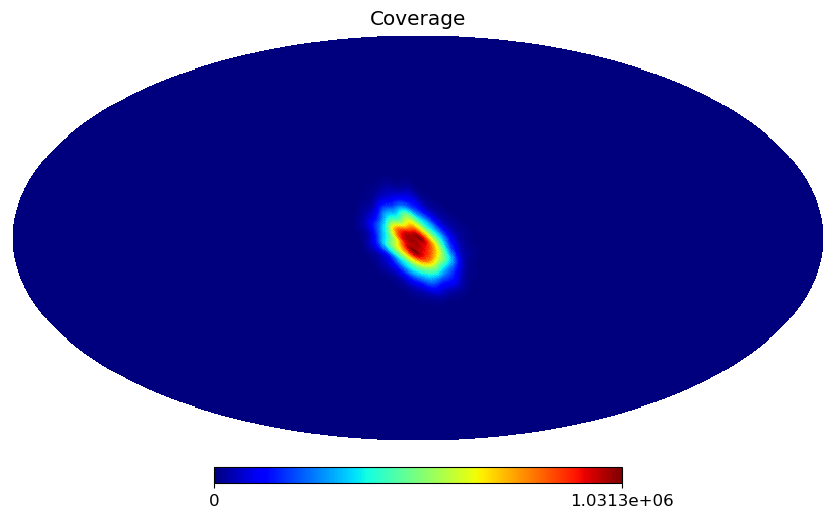

In [33]:
hp.mollview(coverage, title='Coverage', cmap='jet')

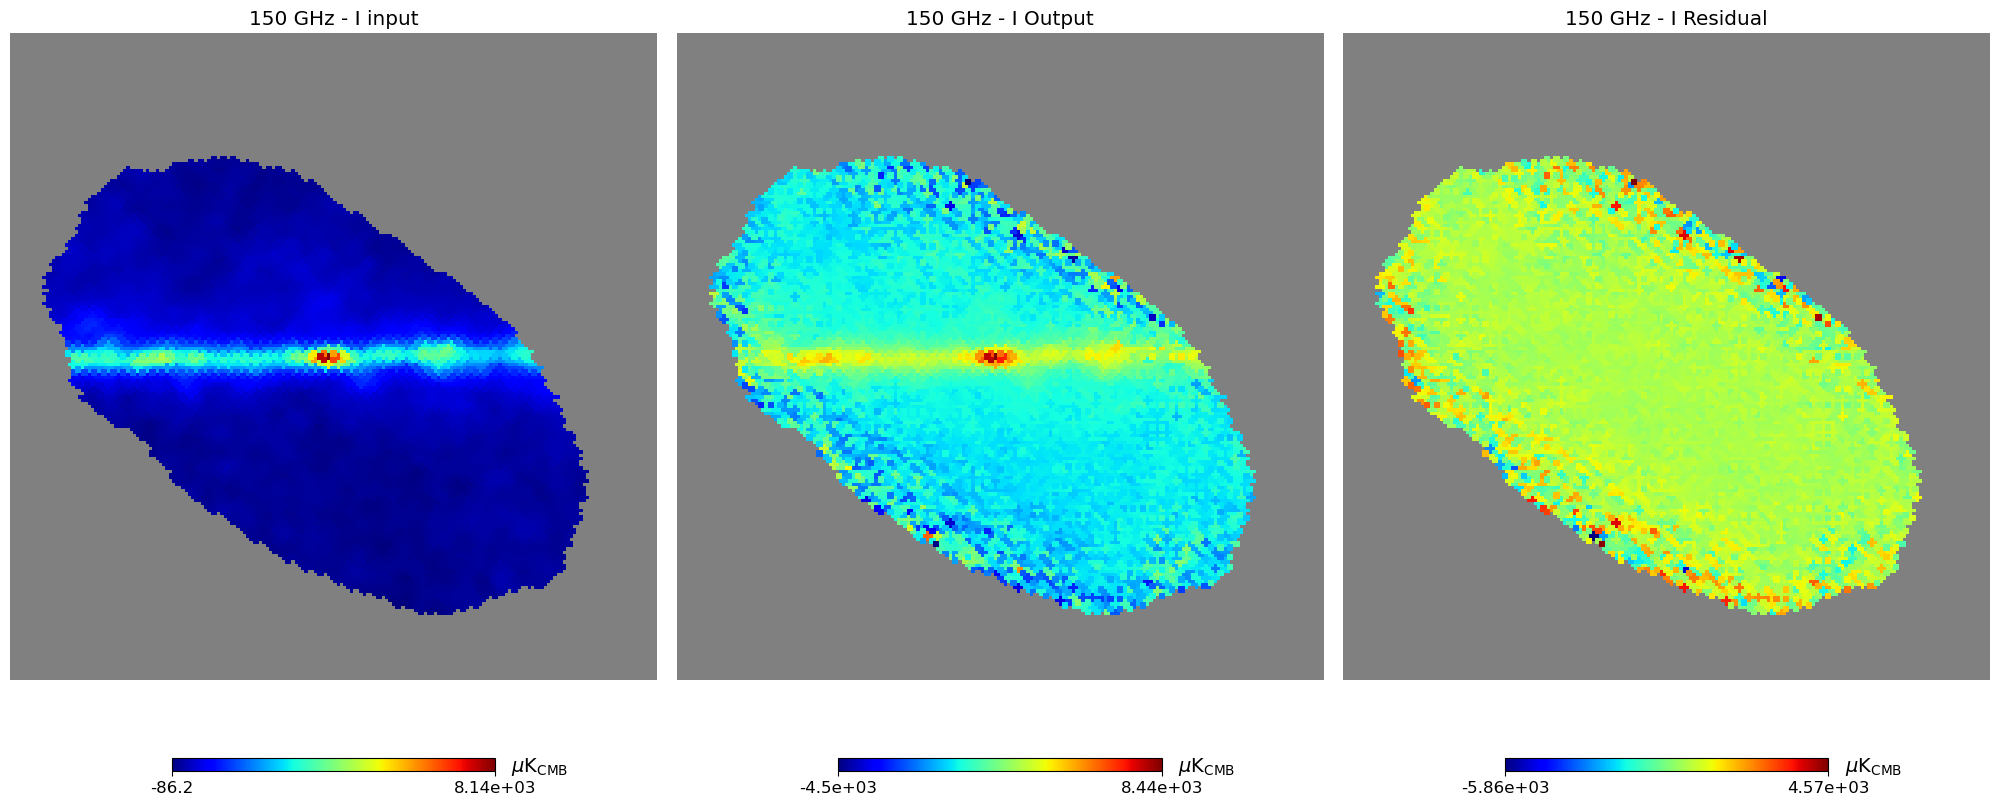

In [34]:
maps_input_mean = np.mean(maps_input[:,:], axis=0)
maps_rec_mean = np.mean(maps_rec[:,:], axis=0)
maps_res_mean = np.mean(maps_res[:,:], axis=0)


plt.figure(figsize=(20, 10))
hp.gnomview((maps_input_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))
    
    
hp.gnomview((maps_rec_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,2))

hp.gnomview((maps_res_mean), rot=center,
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        unit=r'$\mu \mathrm{K_{CMB}}$',
                        #min = - n * sigma_rec,
                        #max = n * sigma_rec,
                        sub=(1,3,3))
    

In [35]:
brightest_pix_input = np.argmax(maps_input_mean)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean[brightest_pix_input]
brightest_val_true = maps_input_mean[brightest_pix_input]


print('coverage pixel centrale', coverage[brightest_pix_input])
print('Pixel centrale mappa input', brightest_val_true)
print('Pixel centrale mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel centrale 1018856.1549544497
Pixel centrale mappa input 8140.484210744878
Pixel centrale mappe ricostruita 8437.651100519048
SNR 27.39364475272188


### Noise estimation and SNR maps

Residual weighted std 460.98340713787013


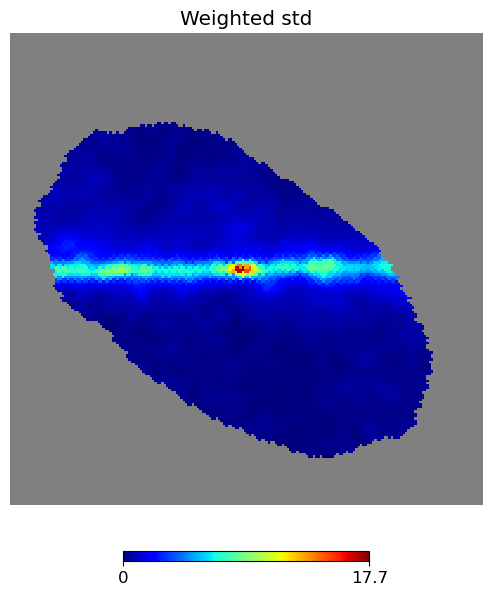

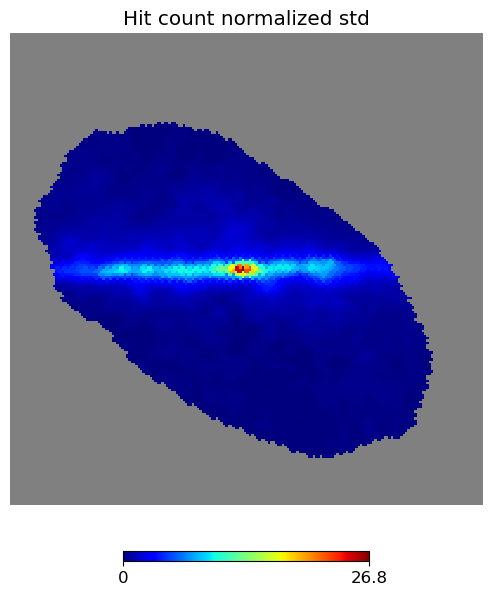

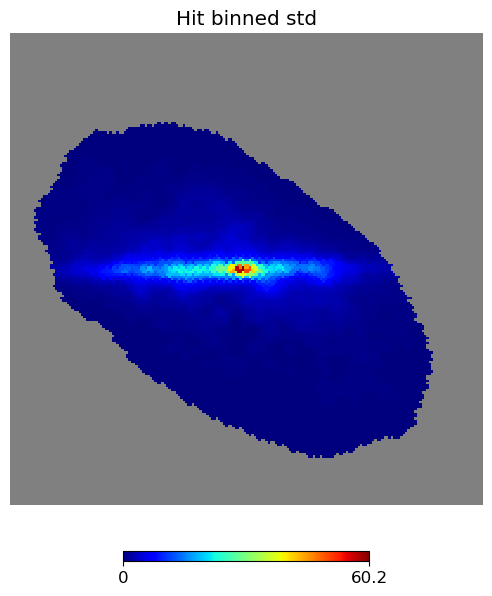

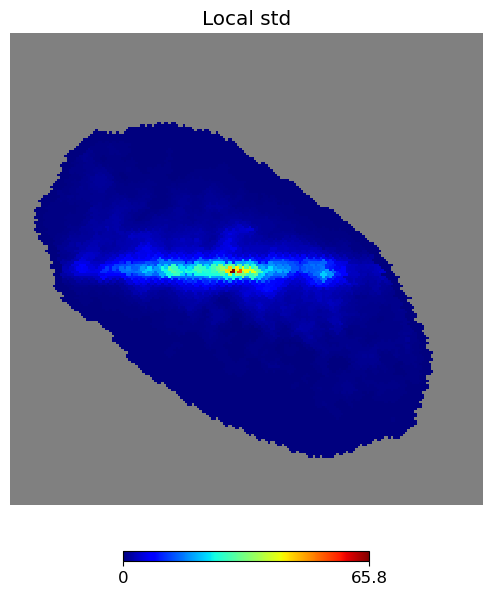

In [36]:
noises = noise_estimation(maps_res_mean, coverage, seenpix)

### SED

In [37]:
brightest_pix_input = np.argmax(maps_input[0,:])   # indice del pixel con valore massimo nelle mappe di input
brightest_pix = np.argmax(maps_rec[0,:])   # indice del pixel con valore massimo nelle mappe ricostruite
theta, phi = hp.pix2ang(128, brightest_pix_input)  # coordinate del pixel più luminoso

In [38]:
brightest_val = maps_rec[:,brightest_pix_input]
brightest_val_true = maps_input[:,brightest_pix_input]

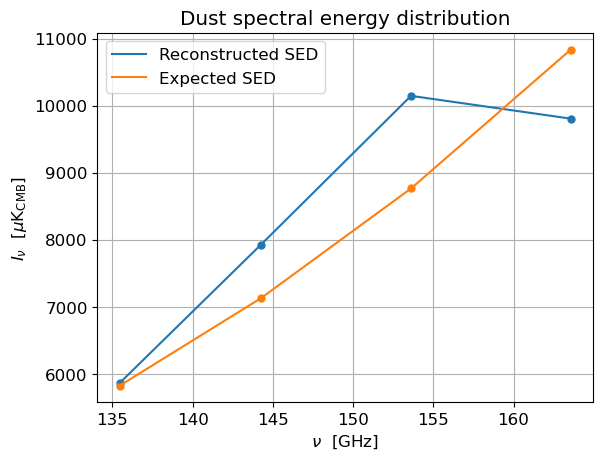

In [39]:
plt.plot(nus[0:4], brightest_val, label='Reconstructed SED')
plt.scatter(nus[0:4], brightest_val, marker='.', s=100)

plt.plot(nus[0:4], brightest_val_true, label='Expected SED')
plt.scatter(nus[0:4], brightest_val_true, marker='.', s=100)


#plt.yscale('log')
plt.xlabel(r'$\nu \ $ [GHz]')
plt.ylabel(r'$I_{\nu} \ \ [\mu \mathrm{K_{CMB}}]$')
plt.title('Dust spectral energy distribution')
plt.grid(which='both', axis='both')
plt.legend()